# 2D Image Decomposition

Decompose 2-D image data into topologically simple basis vectors using **Top-NMF** with a cubical complex.

- **Part A** -- font glyphs (non-overlapping)
- **Part B** -- Ichimatsu (checkerboard) patterns (overlapping)

## Setup

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import torch
from urllib.request import urlretrieve
from collections import deque
from typing import Dict, List, Tuple

from TopNMF import (
    TopologicalNMF,
    CubicalComplex,
    target_diagram_loss,
    generate_ichimatsu_pattern,
    plot_gallery,
)
from TopNMF.visualization import FitMonitor

device = "cpu"

---
## Part A: Character decomposition

### Generate Kanji character images

In [2]:
# Download a CJK font for extracting real glyph components
font_file = "NotoSansCJKjp-Regular.otf"
try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()
font_path = os.path.join(base_dir, font_file)

if not os.path.exists(font_path):
    url = "https://raw.githubusercontent.com/notofonts/noto-cjk/main/Sans/OTF/Japanese/NotoSansCJKjp-Regular.otf"
    urlretrieve(url, font_path)
    print("Font downloaded:", font_path)
else:
    print("Using existing font:", font_path)

Using existing font: /home/keunsu/TopNMF/notebook/NotoSansCJKjp-Regular.otf


Generated 9 images, shape: (9, 64, 64)
Data: (9, 64, 64)


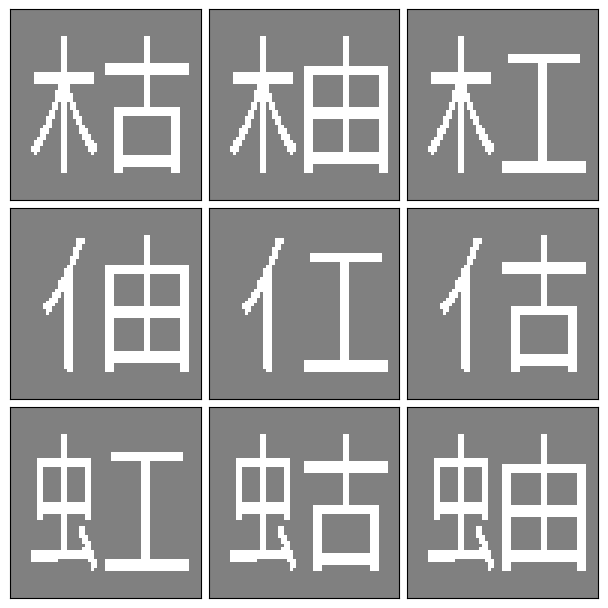

In [3]:
def _crop_to_content(image: np.ndarray) -> np.ndarray:
    """Crop a binary image to its non-zero bounding box."""
    ys, xs = np.nonzero(image)
    if len(xs) == 0:
        raise ValueError("No foreground pixels found while extracting glyph component.")
    y0, y1 = int(ys.min()), int(ys.max()) + 1
    x0, x1 = int(xs.min()), int(xs.max()) + 1
    return image[y0:y1, x0:x1]


def _render_glyph_image(
    char: str,
    font: ImageFont.FreeTypeFont,
    canvas_size: Tuple[int, int],
) -> np.ndarray:
    """Render a centered glyph to a binary image."""
    width, height = canvas_size
    img = Image.new("L", (width, height), color=0)
    draw = ImageDraw.Draw(img)
    bbox = draw.textbbox((0, 0), char, font=font)
    glyph_w, glyph_h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (width - glyph_w) / 2 - bbox[0]
    y = (height - glyph_h) / 2 - bbox[1]
    draw.text((x, y), char, fill=255, font=font)
    arr = np.array(img, dtype=np.uint8)
    return (arr > 127).astype(np.uint8) * 255


def _extract_template_from_glyph(
    glyph: str,
    font: ImageFont.FreeTypeFont,
    target_size: Tuple[int, int],
    canvas_size: Tuple[int, int],
) -> np.ndarray:
    """Render a glyph and resize to target template size."""
    full = _render_glyph_image(glyph, font=font, canvas_size=canvas_size)
    tight = _crop_to_content(full)
    resample_ns = getattr(Image, "Resampling", Image)
    resized = Image.fromarray(tight).resize(target_size, resample=resample_ns.NEAREST)
    return np.array(resized, dtype=np.uint8)

def _pad_templates_for_gallery(templates: Dict[str, np.ndarray], keys: List[str]) -> np.ndarray:
    """Pad variable-size templates so they can be visualized in a single gallery."""
    max_h = max(templates[k].shape[0] for k in keys)
    max_w = max(templates[k].shape[1] for k in keys)
    padded: List[np.ndarray] = []
    for k in keys:
        t = templates[k]
        canvas = np.zeros((max_h, max_w), dtype=np.uint8)
        y0 = (max_h - t.shape[0]) // 2
        x0 = (max_w - t.shape[1]) // 2
        canvas[y0 : y0 + t.shape[0], x0 : x0 + t.shape[1]] = t
        padded.append(canvas)
    return np.stack(padded, axis=0)


def _paste_exact(canvas: np.ndarray, part: np.ndarray, top: int, left: int) -> None:
    """Paste `part` at an exact location; raise if any clipping would occur."""
    part_h, part_w = part.shape
    if top < 0 or left < 0 or top + part_h > canvas.shape[0] or left + part_w > canvas.shape[1]:
        raise ValueError(
            f"Part does not fit at fixed anchor (top={top}, left={left}, shape={part.shape}) "
            f"within canvas shape={canvas.shape}."
        )
    canvas[top : top + part_h, left : left + part_w] = np.maximum(
        canvas[top : top + part_h, left : left + part_w], part
    )


def generate_kanji_overlapping_parts_images(
    image_size: Tuple[int, int] = (64, 64),
    radical_height: int = 46,
    radical_widths: Dict[str, int] | None = None,
    component_size: Tuple[int, int] = (28, 46),
    component_sizes: Dict[str, Tuple[int, int]] | None = None,
    selected_combinations: Dict[str, Tuple[str, str]] | None = None,
    donor_canvas_size: Tuple[int, int] = (96, 96),
    donor_font_size: int = 82,
    radical_anchor: Tuple[int, int] = (9, 4),
    radical_x_offsets: Dict[str, int] | None = None,
    radical_y_offsets: Dict[str, int] | None = None,
    component_anchor: Tuple[int, int] = (9, 32),
    component_y_offsets: Dict[str, int] | None = None,
) -> Tuple[np.ndarray, List[str], Dict[str, object], np.ndarray, np.ndarray]:
    """Synthesize kanji images from connected font-derived templates.

    Parameters
    ----------
    selected_combinations : dict[str, tuple[str, str]] or None
        Mapping of output label -> (radical, component).
        If None, all 3x3 combinations are generated.
    """
    height, width = image_size
    radicals = list(radical_x_offsets.keys())
    components = list(component_y_offsets.keys())

    for label, (radical, component) in selected_combinations.items():
        if radical not in radicals:
            raise ValueError(f"Unknown radical in selected_combinations[{label!r}]: {radical}")
        if component not in components:
            raise ValueError(f"Unknown component in selected_combinations[{label!r}]: {component}")

    font_file = "NotoSansCJKjp-Regular.otf"
    font_candidates = [
        os.path.join(os.getcwd(), font_file),
        os.path.join(os.getcwd(), "notebook", font_file),
    ]
    try:
        font_candidates.insert(0, os.path.join(os.path.dirname(os.path.abspath(__file__)), font_file))
    except NameError:
        pass

    font_path = next((p for p in font_candidates if os.path.exists(p)), None)
    font = ImageFont.truetype(font_path, donor_font_size)

    radical_templates = {
        r: _extract_template_from_glyph(
            glyph=r,
            font=font,
            target_size=(int(radical_widths[r]), int(radical_height)),
            canvas_size=donor_canvas_size,
        )
        for r in radicals
    }
    component_templates = {
        c: _extract_template_from_glyph(
            glyph=c,
            font=font,
            target_size=component_sizes[c],
            canvas_size=donor_canvas_size,
        )
        for c in components
    }

    radical_stack = _pad_templates_for_gallery(radical_templates, radicals)
    component_stack = _pad_templates_for_gallery(component_templates, components)

    rad_top, rad_left = radical_anchor
    comp_top, comp_left = component_anchor

    images: List[np.ndarray] = []
    labels: List[str] = []
    for label, (radical, component) in selected_combinations.items():
        canvas = np.zeros((height, width), dtype=np.uint8)
        _paste_exact(
            canvas,
            radical_templates[radical],
            top=rad_top + radical_y_offsets[radical],
            left=rad_left + radical_x_offsets[radical],
        )
        _paste_exact(
            canvas,
            component_templates[component],
            top=comp_top + component_y_offsets[component],
            left=comp_left,
        )
        images.append(canvas)
        labels.append(label)

    group_info = {
        "radicals": radicals,
        "components": components,
        "radical_widths": radical_widths,
        "anchors": {"radical": radical_anchor, "component": component_anchor},
        "radical_x_offsets": radical_x_offsets,
        "radical_y_offsets": radical_y_offsets,
        "component_sizes": component_sizes,
        "component_y_offsets": component_y_offsets,
        "selected_combinations": selected_combinations,
    }
    return np.stack(images, axis=0), labels, group_info, radical_stack, component_stack


images_kanji, labels_kanji, groups_kanji, radical_templates, component_templates = (
    generate_kanji_overlapping_parts_images(
        radical_widths={"木": 22, "亻": 14, "虫": 22},
        radical_x_offsets={"木": 3, "亻": 7, "虫": 3},
        radical_y_offsets={"木": 0, "亻": 0, "虫": 0},
        component_sizes={"工": (28, 40), "古": (28, 46), "由": (28, 46)},
        component_y_offsets={"工": 6, "古": 0, "由": 0},
        selected_combinations = {
            "枯": ("木", "古"),
            "柚": ("木", "由"),
            "杠": ("木", "工"),
            "伷": ("亻", "由"),
            "仜": ("亻", "工"),
            "估": ("亻", "古"),
            "虹": ("虫", "工"),
            "蛄": ("虫", "古"),
            "蚰": ("虫", "由"),
        },
        radical_anchor=(9, 4),
        component_anchor=(9, 32),
    )
)
print(f"Generated {len(labels_kanji)} images, shape: {images_kanji.shape}")

# Keep exact binary patterns for linear basis extraction
X_kanji = (images_kanji > 127).astype(np.float32)

n_components_kanji = len(groups_kanji["radicals"]) + len(groups_kanji["components"])
data_dims_kanji = X_kanji.shape[1:]

X_kanji_flat = X_kanji.reshape(X_kanji.shape[0], -1)

print(f"Data: {X_kanji.shape}")
n_col = min(3, X_kanji.shape[0])
n_row = int(np.ceil(X_kanji.shape[0] / n_col))
_ = plot_gallery(X_kanji, n_row=n_row, n_col=n_col)


### Fit Top-NMF

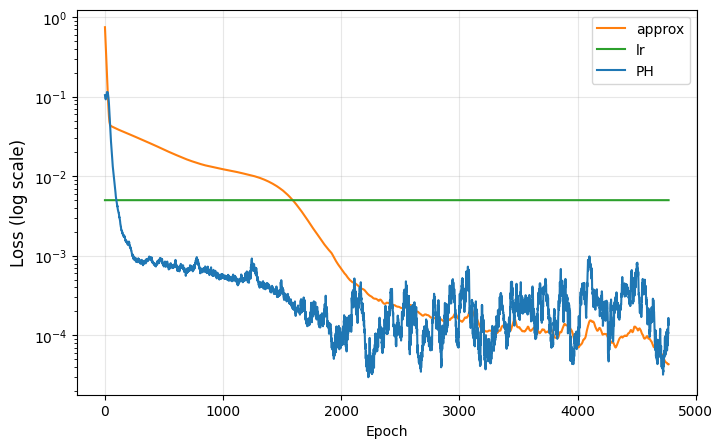

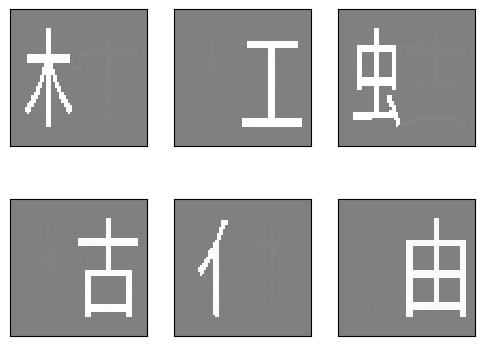

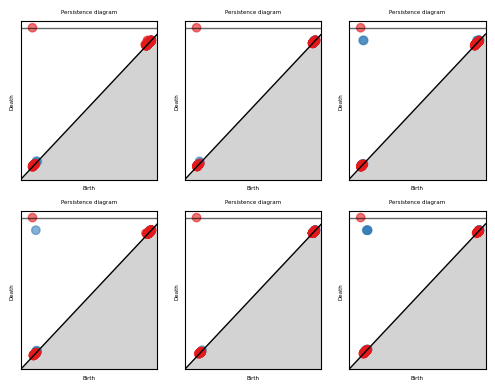

  0%|          | 0/5000 [00:00<?, ?it/s]

Final reconstruction loss: 0.0001


In [4]:
target_diagrams_kanji = [
    torch.tensor([[]], dtype=torch.float, device=device),
    torch.tensor([[]], dtype=torch.float, device=device),
]

cubical_kanji = CubicalComplex(superlevel=True, dim=len(data_dims_kanji), mode="V")

model_kanji = TopologicalNMF(
    n_components=n_components_kanji,
    device=device,
    random_state=42,
    complex=cubical_kanji,
    ph_loss_fn=target_diagram_loss,
    data_shape=data_dims_kanji,
    use_embedding=False,
)

monitor_kanji = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=10,
    grid=(2, 3),
    PHmode="V",
    superlevel=True,
)

model_kanji.fit(
    X_kanji_flat,
    n_iterations=5000,
    lr=0.005,
    PH_dims=[0],
    lambda_top=0.4,
    weight_decay=0.1,
    verbose=True,
    target_diagrams=target_diagrams_kanji,
    init_method="nndsvda",
    monitor=monitor_kanji,
)

V_kanji = model_kanji.V.detach().cpu().numpy()
print(f"Final reconstruction loss: {model_kanji.losses['approx'][-1]:.4f}")
plt.close("all")

### Compare with standard NMF

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

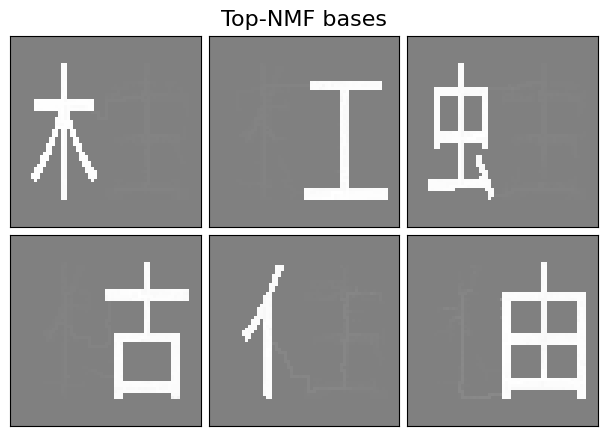

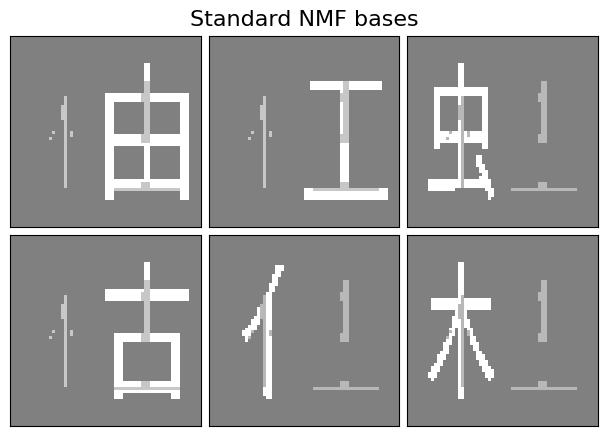

In [5]:
from sklearn.decomposition import NMF

plot_gallery(
    V_kanji.reshape(-1, *data_dims_kanji),
    title="Top-NMF bases",
    n_row=2,
    n_col=3,
)

nmf_kanji = NMF(n_components=n_components_kanji, init="nndsvda", random_state=0)
nmf_kanji.fit_transform(X_kanji_flat)
H_kanji_std = nmf_kanji.components_

plot_gallery(
    H_kanji_std.reshape(-1, *data_dims_kanji),
    title="Standard NMF bases",
    n_row=2,
    n_col=3,
)

### Generate Hangul character images

In [6]:
# Download the Nanum Gothic font for rendering Hangul characters
if not os.path.exists("NanumGothicCoding-Regular.ttf"):
    url = "https://github.com/google/fonts/raw/main/ofl/nanumgothiccoding/NanumGothicCoding-Regular.ttf"
    urlretrieve(url, "NanumGothicCoding-Regular.ttf")
    print("Font downloaded.")

Font downloaded.


In [7]:
def generate_hangul_images(image_size=(64, 64), font_size=48):
    """Render six Hangul characters as grayscale images."""
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()

    labels = ['가','다','라','갸','댜','랴']
    font_path = os.path.join(base_dir, "NanumGothicCoding-Regular.ttf")
    font = ImageFont.truetype(font_path, font_size)
    W, H = image_size
    images = []

    for ch in labels:
        img = Image.new('L', (W, H), color=0)
        draw = ImageDraw.Draw(img)
        bbox = draw.textbbox((0, 0), ch, font=font)
        w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
        draw.text(((W - w) / 2, (H - h) / 2), ch, fill=255, font=font)
        images.append(np.array(img, dtype=np.uint8))

    return np.stack(images, axis=0), labels

images_array, labels = generate_hangul_images(font_size=48)
print(f"Generated {len(labels)} images, shape: {images_array.shape}")

Generated 6 images, shape: (6, 64, 64)


Data: (6, 64, 64)


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
      dtype=object)

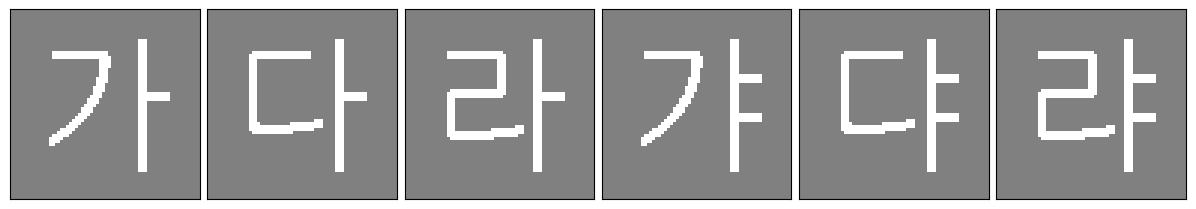

In [8]:
# Binarize and add random intensity variation
X_hangul = (images_array > 127).astype(np.float32)

n_components_hangul = 5
data_dims_hangul = X_hangul.shape[1:]  # (64, 64)

print(f"Data: {X_hangul.shape}")
plot_gallery(X_hangul, n_row=1, n_col=6)

### Fit Top-NMF

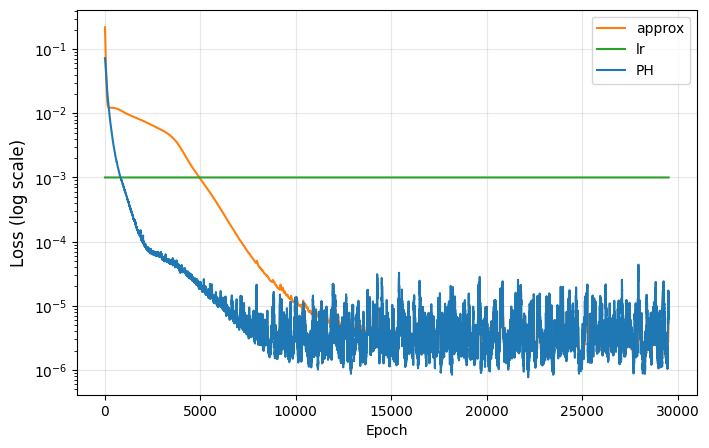

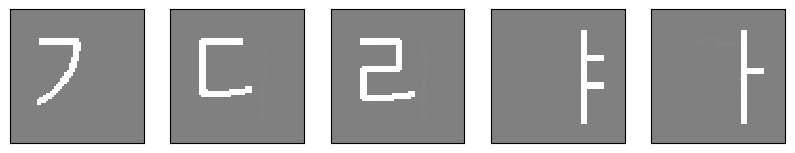

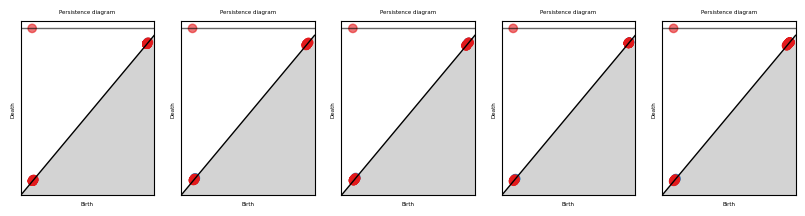

  0%|          | 0/30000 [00:00<?, ?it/s]

Final reconstruction loss: 0.0000


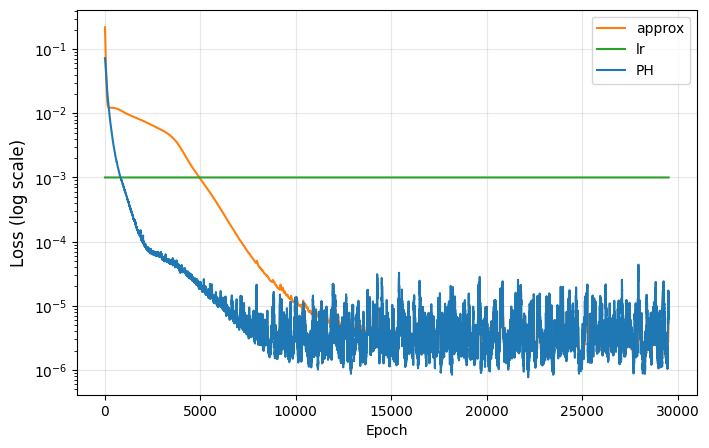

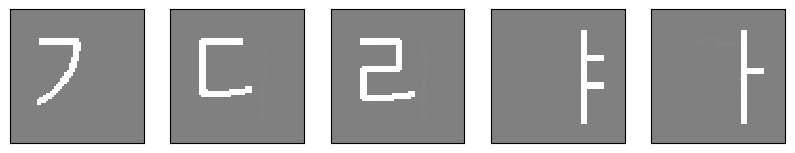

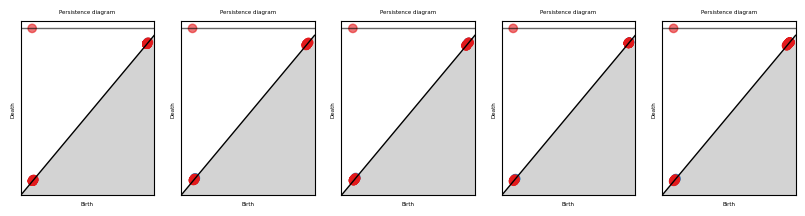

In [9]:
# Empty target diagrams encourage topologically simple bases
target_diagrams_hangul = [
    torch.tensor([[]], dtype=torch.float, device=device),
    torch.tensor([[]], dtype=torch.float, device=device),
]

# Vertex-based superlevel cubical complex for 2-D images
cubical_hangul = CubicalComplex(superlevel=True, dim=len(data_dims_hangul), mode="V")

model_hangul = TopologicalNMF(
    n_components=n_components_hangul,
    device=device,
    random_state=42,
    complex=cubical_hangul,
    ph_loss_fn=target_diagram_loss,
    data_shape=data_dims_hangul,
    use_embedding=False,
)

monitor_hangul = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=10,
    grid=(1, 5),
    PHmode="V",
    superlevel=True,
)

# Flatten spatial dims for NMF: (n_samples, n_features)
X_hangul_flat = X_hangul.reshape(X_hangul.shape[0], -1)

model_hangul.fit(
    X_hangul_flat,
    n_iterations=30000,
    lr=0.001,
    PH_dims=[0],
    lambda_top=0.7,
    weight_decay=0.2,
    verbose=True,
    target_diagrams=target_diagrams_hangul,
    init_method="nndsvda",
    monitor=monitor_hangul,
)

V_hangul = model_hangul.V.detach().cpu().numpy()
print(f"Final reconstruction loss: {model_hangul.losses['approx'][-1]:.4f}")

### Compare with standard NMF

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

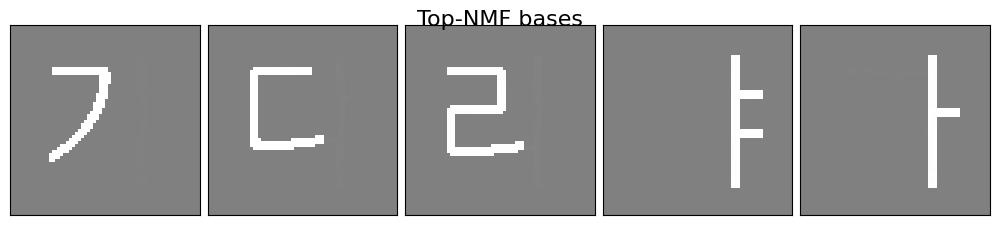

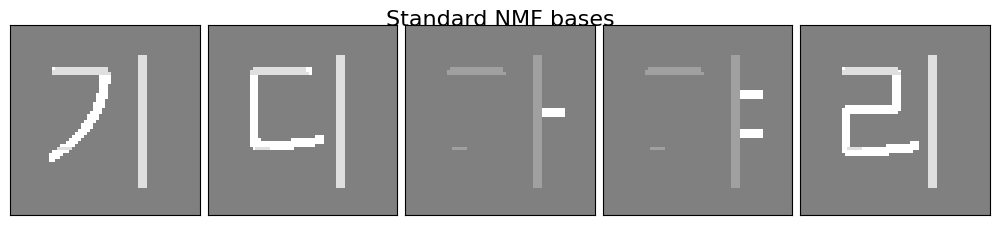

In [10]:
from sklearn.decomposition import NMF

# Top-NMF basis vectors
plot_gallery(V_hangul.reshape(-1, *data_dims_hangul), title="Top-NMF bases", n_row=1, n_col=5)

# Standard NMF for comparison
nmf = NMF(n_components=n_components_hangul, init="nndsvda", random_state=0)
nmf.fit_transform(X_hangul_flat)
H_std = nmf.components_

plot_gallery(H_std.reshape(-1, *data_dims_hangul), title="Standard NMF bases", n_row=1, n_col=5)

---
## Part B: Ichimatsu pattern decomposition

### Generate ichimatsu patterns

Data: (40, 81)


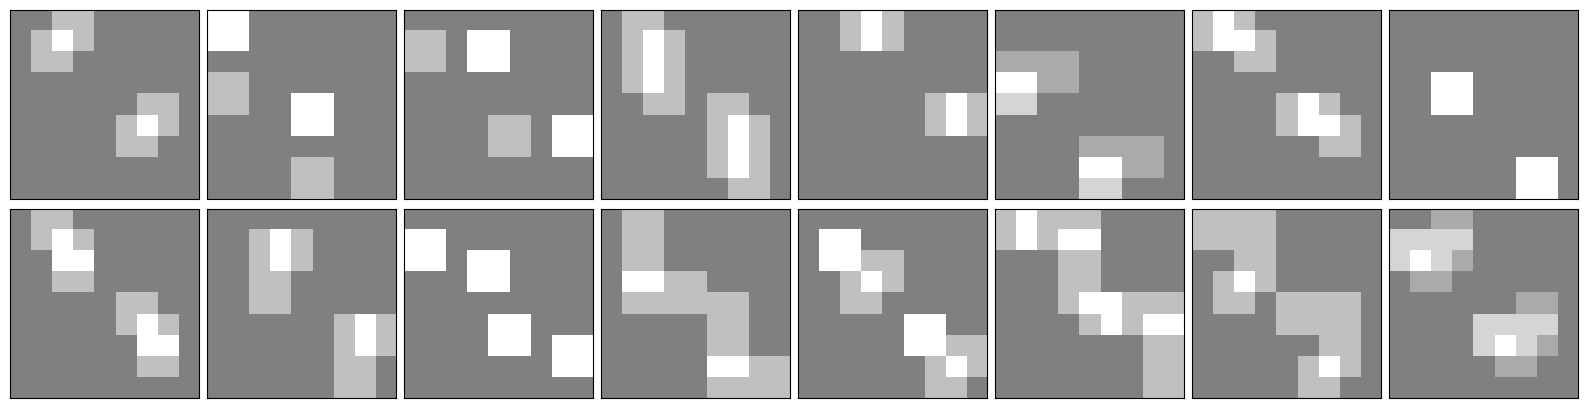

In [11]:
image_shape = (9, 9)

# Define a 6x6 checkerboard kernel
pat = np.zeros((6, 6))
pat[0:2, 0:2] = 1
pat[4:6, 4:6] = 1

# Generate 40 random placements with 2-5 pattern repetitions
X_ichi = generate_ichimatsu_pattern(
    num_samples=40, image_shape=image_shape,
    pat=pat, pat_step=1, min_pat=2, max_pat=5, seed=42,
)
X_ichi /= np.max(X_ichi, axis=(1, 2), keepdims=True)  # normalise to [0, 1]

plot_gallery(X_ichi, n_row=2, n_col=8)

# Flatten to (n_samples, n_features) for NMF
X_ichi_flat = X_ichi.reshape(X_ichi.shape[0], -1)
print(f"Data: {X_ichi_flat.shape}")

### Fit Top-NMF

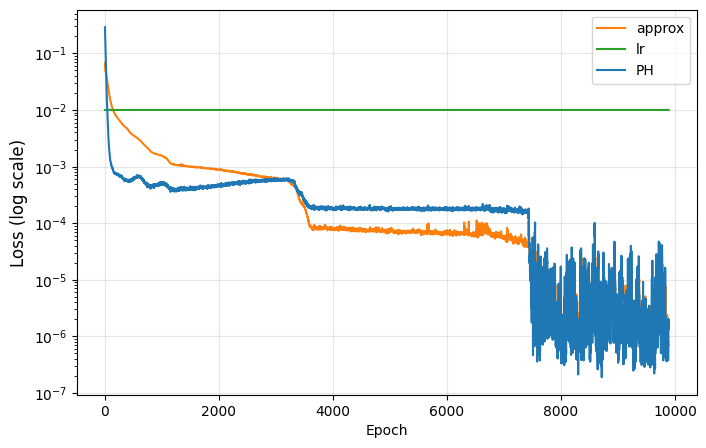

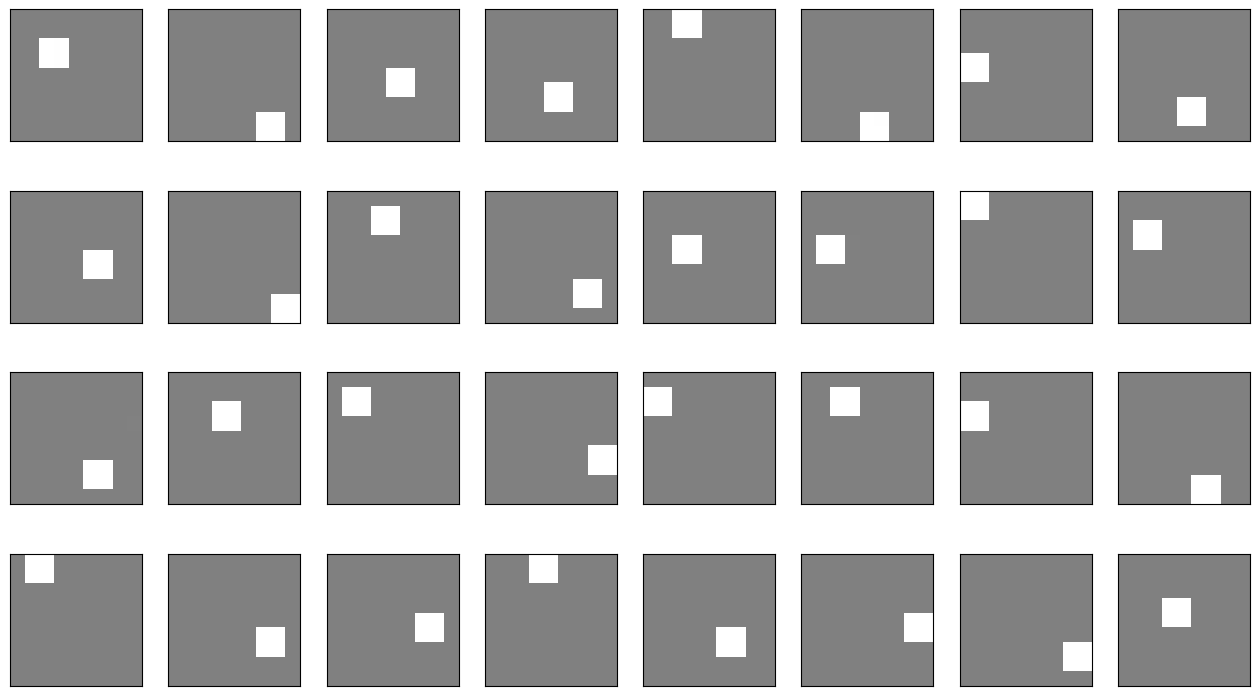

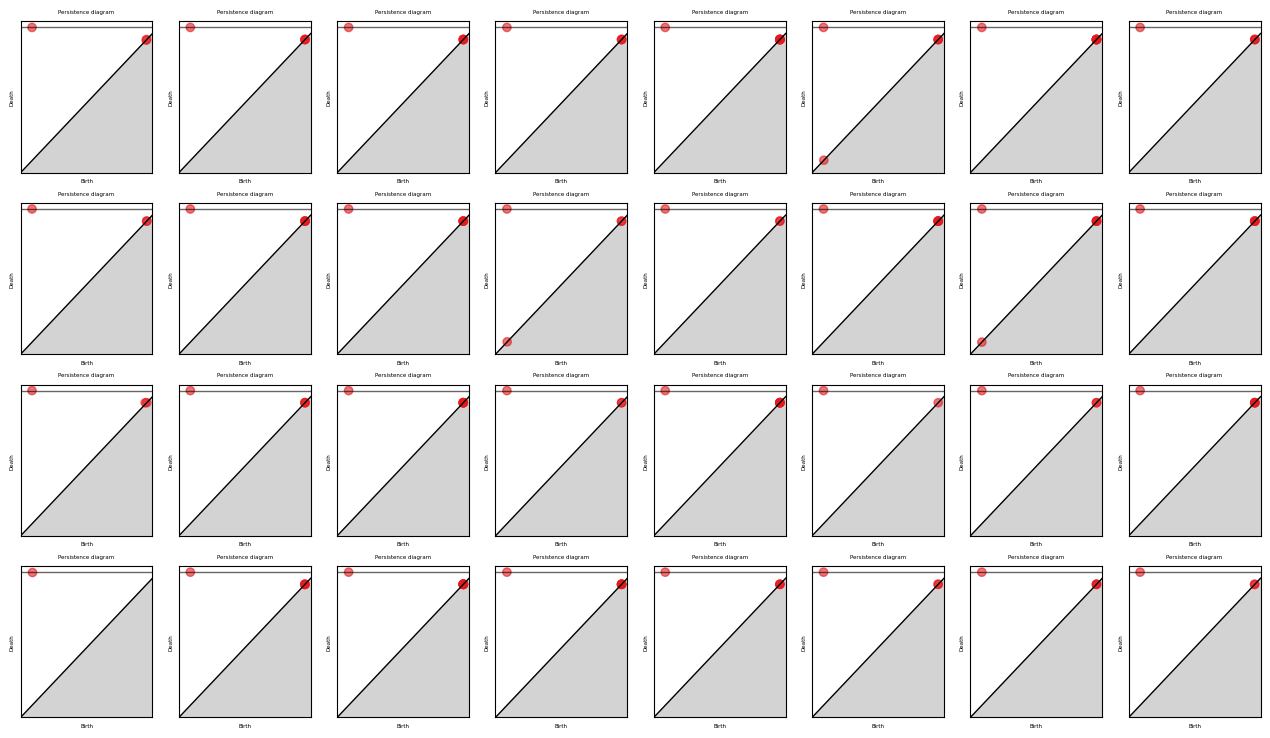

  0%|          | 0/10000 [00:00<?, ?it/s]

In [12]:
# Vertex-based superlevel cubical complex
cubical_ichi = CubicalComplex(superlevel=True, dim=len(image_shape), mode="V")

target_diagrams_ichi = [
    torch.tensor([[]], dtype=torch.float, device=device),
    torch.tensor([[]], dtype=torch.float, device=device),
]

model_ichi = TopologicalNMF(
    n_components=32,
    device=device,
    complex=cubical_ichi,
    ph_loss_fn=target_diagram_loss,
    data_shape=image_shape,
    use_embedding=False,
    random_state=42,
)

monitor_ichi = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=10,
    grid=(4, 8),
    PHmode="V",
    superlevel=True,
)

model_ichi.fit(
    X_ichi_flat,
    n_iterations=10000,
    lr=0.01,
    lambda_top=0.7,
    weight_decay=0.2,
    PH_dims=[0],
    start_epoch_topological=0,
    verbose=True,
    target_diagrams=target_diagrams_ichi,
    init_method="nndsvdar",
    monitor=monitor_ichi,
)

plt.close("all")